=== SUPERVISED LEARNING ===



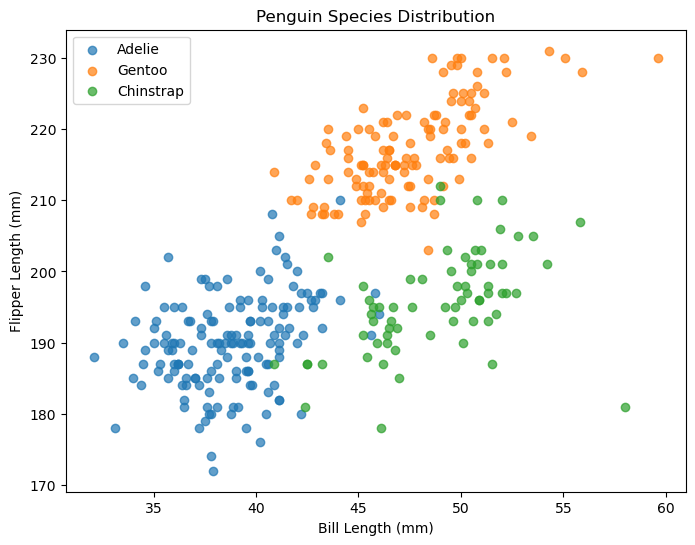

Model 1: Logistic Regression
Accuracy: 1.0
Confusion Matrix:
[[31  0  0]
 [ 0 18  0]
 [ 0  0 18]]

Model 2: Random Forest
Accuracy: 1.0
Confusion Matrix:
[[31  0  0]
 [ 0 18  0]
 [ 0  0 18]]

=== UNSUPERVISED LEARNING (HIERARCHICAL CLUSTERING) ===



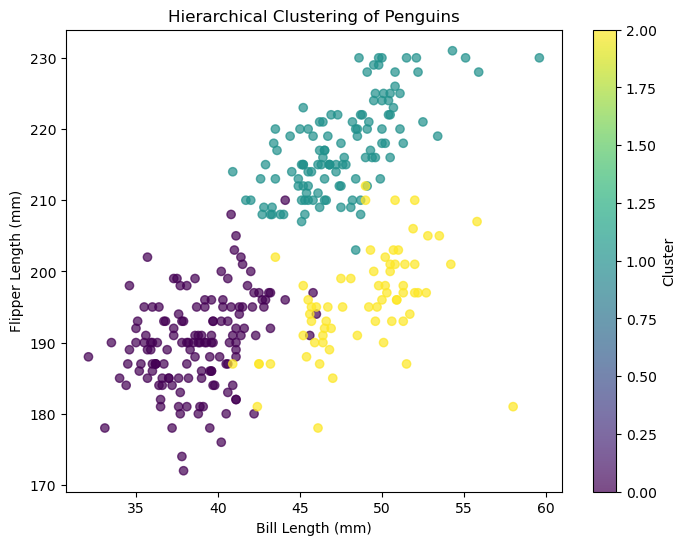

Hierarchical Clustering
Unique Clusters: {0, 1, 2}


In [4]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import accuracy_score, confusion_matrix

df = pd.read_csv("penguins.csv")

print("=== SUPERVISED LEARNING ===\n")

plt.figure(figsize=(8,6))
for sp in df['species'].unique():
    subset = df[df['species'] == sp]
    plt.scatter(subset['bill_length_mm'], subset['flipper_length_mm'], 
                label=sp, alpha=0.7)

plt.xlabel("Bill Length (mm)")
plt.ylabel("Flipper Length (mm)")
plt.title("Penguin Species Distribution")
plt.legend()
plt.show()

df = df.dropna()
df = pd.get_dummies(df, columns=['sex', 'island'], drop_first=True)

X = df.drop('species', axis=1)
y = df['species']

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Model 1: Logistic Regression")
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr), 3))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print()

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Model 2: Random Forest")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 3))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\n=== UNSUPERVISED LEARNING (HIERARCHICAL CLUSTERING) ===\n")

hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['cluster'] = hc.fit_predict(scaler.transform(X))

plt.figure(figsize=(8,6))
plt.scatter(df['bill_length_mm'], df['flipper_length_mm'],
            c=df['cluster'], cmap='viridis', alpha=0.7)

plt.xlabel("Bill Length (mm)")
plt.ylabel("Flipper Length (mm)")
plt.title("Hierarchical Clustering of Penguins")
plt.colorbar(label='Cluster')
plt.show()

print("Hierarchical Clustering")
print("Unique Clusters:", set(df['cluster']))